# Les photos d'entrée manquantes : d'où viennent-elles vraiment ?

L'étape 1 de la fiche mesure, pour chaque **arrivé qui est resté**, s'il a déposé sa **photo d'entrée**
(son portefeuille d'ouverture). Le compte de base : **223 / 312** présentes.

Ce notebook répond à la question *à qui la faute pour les 89 absentes ?* — sans se fier à l'étiquette du
registre, en **ouvrant les caches OCR**. Il est autonome et ne fait **aucun appel API** : il relit le cache
de résolution `ticker_llm_cache.json` déjà constitué.


## 1 — L'étiquette du registre est trompeuse : « scanné, hors périmètre » ≠ « jamais océrisé »


In [1]:
import pandas as pd, os, glob, json, re
V1T = "cache/tables"; REF = "reference"
led = pd.read_csv(f"{V1T}/02_ledger_docs.csv", low_memory=False); led["doc_id"] = led["doc_id"].astype(str)

def stems(d): return {os.path.splitext(os.path.basename(p))[0] for p in glob.glob(f"{d}/**/*.json", recursive=True)}
caches = {"ocr_cache_fd_v1": stems(f"{REF}/ocr_cache_fd_v1"),
          "ocr_cache (txns)": stems("../00_recuperation_donnees/data/house/ocr_cache"),
          "ocr_cache_v1": stems(f"{REF}/ocr_cache_v1"),
          "ocr_cache_echantillon": stems("../00_recuperation_donnees/data/house/ocr_cache_echantillon")}
allocr = set().union(*caches.values())
shv = set(led.loc[led["statut"] == "scanne_hors_V1", "doc_id"])

t08 = set(pd.read_csv(f"{V1T}/08_holdings_fd_ocr.csv", low_memory=False, usecols=["doc_id"])["doc_id"].astype(str))
t09 = set(pd.read_csv(f"{V1T}/09_transactions_fd_ocr.csv", low_memory=False, usecols=["doc_id"])["doc_id"].astype(str))

print(f"documents étiquetés « scanne_hors_V1 » (crus hors périmètre)      : {len(shv):,}")
print(f"  … qui ont EN RÉALITÉ un JSON OCR quelque part                   : {len(shv & allocr):,}")
print(f"  … réellement sans aucun JSON                                    : {len(shv - allocr):,}")
print(f"JSON OCR présents mais chargés dans AUCUNE table (08/09)          : {len(allocr - t08 - t09):,}")


documents étiquetés « scanne_hors_V1 » (crus hors périmètre)      : 2,851
  … qui ont EN RÉALITÉ un JSON OCR quelque part                   : 2,842
  … réellement sans aucun JSON                                    : 9
JSON OCR présents mais chargés dans AUCUNE table (08/09)          : 2,814


→ L'écrasante majorité des documents « hors périmètre » **ont bien été océrisés**. L'étiquette du registre
date d'avant l'OCR et n'a pas été rafraîchie. La fiche ne peut donc pas parler de *documents pas exploités*.


## 2 — Les 389 JSON océrisés jamais chargés : que contiennent-ils ?


In [2]:
fd = {os.path.splitext(os.path.basename(p))[0]: p for p in glob.glob(f"{REF}/ocr_cache_fd_v1/**/*.json", recursive=True)}
cible = sorted((shv & set(fd)) - t08 - t09)

def real_holdings(o):
    h = o.get("holdings")
    if isinstance(h, list) and h and all(isinstance(x, str) and len(x) <= 2 for x in h[:5]):
        try: p = json.loads("".join(h))
        except Exception: return []
        h = p.get("holdings", []) if isinstance(p, dict) else p
    return h if isinstance(h, list) else []

rows = []
for d in cible:
    o = json.load(open(fd[d])); H = real_holdings(o)
    rows.append((d, o.get("filing_type"), o.get("status"), len(H)))
mis = pd.DataFrame(rows, columns=["doc_id", "filing_type", "status", "n"])
print(f"389 documents océrisés non chargés :")
print(f"  · vides (rien à déclarer)          : {int((mis['n'] == 0).sum())}")
print(f"  · avec du contenu                  : {int((mis['n'] > 0).sum())}  "
      f"({int(mis.loc[mis['n']>0,'n'].sum())} lignes de patrimoine)")
print(f"  types des non-vides : {mis.loc[mis['n']>0,'filing_type'].value_counts().to_dict()}")


389 documents océrisés non chargés :
  · vides (rien à déclarer)          : 312
  · avec du contenu                  : 77  (431 lignes de patrimoine)
  types des non-vides : {'C': 53, 'A': 24}


→ 312 sont **vraiment vides** (`nothing_to_report`). 77 portent du contenu — mais surtout de vieilles
candidatures papier : **immobilier, sociétés privées, comptes bancaires, fonds** ; très peu d'actions cotées.


## 3 — La vraie récupération : tickériser les titres écrits en toutes lettres

Le patrimoine scanné est déjà dans l'analyse (électronique ⊕ OCR). Ce qui reste sans titre reconnu, ce sont
des lignes où le nom est écrit **en toutes lettres** sans ticker entre parenthèses (« Baidu, Inc. »,
« iShares Core S&P Mid Cap ETF »). Le résolveur maison a été passé dessus ; on relit son **cache** (aucun
appel API ici), avec un **garde-fou** : on refuse un ticker posé sur une ligne à code non-equity (`[BA]`
compte bancaire, `[RP]` immobilier, `[OL]`…).


In [3]:
import yaml
cols = ["doc_id","filing_type","bioguide","filing_date","asset_description","ticker","value_lo","value_hi","conteneur_nu"]
h11e = pd.read_csv(f"{V1T}/11_holdings_complets.csv", low_memory=False, usecols=cols)
ocr  = pd.read_csv(f"{V1T}/08_holdings_fd_ocr.csv", low_memory=False)
ocr.loc[ocr["ticker"].isin({"EIF","DC","JT","SP","MF","EF","RP","OL"}), "ticker"] = None
ocr["conteneur_nu"] = ocr["asset_description"].astype(str).str.rstrip().str.endswith("⇒")
h11 = pd.concat([h11e, ocr.reindex(columns=cols)], ignore_index=True)
h11["filing_date"] = pd.to_datetime(h11["filing_date"], errors="coerce")

cache = json.load(open("../00_recuperation_donnees/data/house/ticker_llm_cache.json"))["mappings"]
BAD = re.compile(r"(?i)(\[BA\]|\[RP\]|\[OL\]|\[DO\]|\[IP\]|\[FA\])")
good = {k: v for k, v in cache.items() if v and not BAD.search(str(k))}
print(f"cache de résolution : {len(cache):,} noms · retenus (garde-fou) : {len(good):,}")

# classe_ligne v8 (identique au moteur)
CODES={"EIF","DC","JT","SP","MF","EF","RP","OL","IH","WU","PS","VA","AB","OT","HE","IC","FA","SA","OI"}
AMB={"BA","GS","ST","CS","PE"}; MON={"SPAXX","FDRXX","FZDXX","SWVXX","VMFXX","SPRXX","FCASH"}
RC=re.compile(r"(?i)(merrill|mesirow|fidelity|schwab|betterment|morgan stanley|wells fargo|brokerage|\bIRA\b|401\s?k|trust)")
RF=re.compile(r"(?i)(\bfund\b|\bindex\b|\bportfolio\b|institutional)")
def classe_ligne(t, lib):
    t=str(t).upper().strip(); lib=str(lib) if lib==lib else ""
    if t in CODES: return "faux_ticker"
    if t in AMB and RC.search(lib): return "faux_ticker"
    if t in MON: return "monetaire"
    if len(t)==5 and t.endswith("X"): return "fonds"
    if RF.search(str(lib).split("⇒")[-1]): return "fonds"
    return "negociable"

# a-une-photo = un doc H/C avec ≥1 ligne tickérisée (garde-fou candidat : ≤365 j avant un début de mandat)
mandats = {}
for f in ("legislators-current.yaml", "legislators-historical.yaml"):
    for p in yaml.safe_load(open(os.path.join(REF, f))):
        tt = [(x["start"], x["end"]) for x in p["terms"] if x["type"] == "rep"]
        if tt: mandats[p["id"]["bioguide"]] = tt
e15 = pd.read_csv(f"{V1T}/15_portefeuille_entree.csv")
def a_une_photo(h):
    def da(b, d):
        o = [pd.Timestamp(s) for s, _ in mandats.get(b, []) if pd.Timestamp(s) >= pd.Timestamp(d)]
        return min(o) if o else None
    cand = h[h["filing_type"].isin(["H","C"]) & h["ticker"].notna() & h["bioguide"].notna()].dropna(subset=["filing_date"])
    ok = set(e15["bioguide"])
    for b, g in cand.groupby("bioguide"):
        if (g["filing_type"] == "H").any(): ok.add(b); continue
        for _, x in g[g["filing_type"] == "C"].iterrows():
            d = da(b, x["filing_date"])
            if d is not None and (d - pd.Timestamp(x["filing_date"])).days <= 365: ok.add(b); break
    return ok

reg = pd.read_csv(f"{V1T}/14_registre_membres.csv")
Q = {q: set(reg.loc[reg["quadrant"] == q, "bioguide"]) for q in ["arrivés restés", "cycle complet"]}
avant = a_une_photo(h11)
h2 = h11.copy()
fill = h2["ticker"].isna() & h2["asset_description"].map(lambda d: good.get(str(d)) is not None)
h2.loc[fill, "ticker"] = h2.loc[fill, "asset_description"].map(lambda d: good.get(str(d)))
apres = a_une_photo(h2)

tab = pd.DataFrame({q: {"attendu": len(Q[q]), "observé (base)": len(Q[q] & avant),
                       "observé (après récup.)": len(Q[q] & apres),
                       "récupérés": len(Q[q] & apres) - len(Q[q] & avant)} for q in Q}).T
display(tab)
recup = (apres - avant) & (Q["arrivés restés"] | Q["cycle complet"])
print(f"membres qui n'avaient AUCUNE photo et en ont une : {len(recup)}")


cache de résolution : 23,405 noms · retenus (garde-fou) : 9,498


,attendu,observé (base),observé (après récup.),récupérés
arrivés restés,312,223,230,7
cycle complet,149,96,108,12


membres qui n'avaient AUCUNE photo et en ont une : 19


## 4 — Le résidu : à qui la faute, vraiment ?


In [4]:
manq = Q["arrivés restés"] - apres            # arrivés-restés encore sans photo à titre reconnu
ident = pd.read_csv(f"{V1T}/06_identites_v1.csv", low_memory=False)
lb = led.merge(ident[["last","first","suffix","state_district","bioguide"]].dropna(subset=["bioguide"]),
               on=["last","first","suffix","state_district"], how="left")
g = lb[lb["filing_type"].isin(["H","C"]) & lb["bioguide"].isin(manq)]
a_un_doc = set(g["bioguide"].dropna())
a_des_lignes = set(h2.loc[h2["filing_type"].isin(["H","C"]) & h2["bioguide"].isin(manq), "bioguide"].dropna())
rien   = manq - a_un_doc
sans_action = manq & a_des_lignes
scan_vide = a_un_doc - a_des_lignes
print(f"arrivés-restés sans photo à titre reconnu : {len(manq)}")
print(f"  · n'ont RIEN déposé (réalité)                              : {len(rien)}")
print(f"  · ont déposé mais AUCUNE action cotée (immo/privé/fonds)   : {len(sans_action)}")
print(f"  · scan exploité mais 0 ligne extraite (illisible)         : {len(scan_vide)}")
print("\néchantillon de ce que détiennent les « sans action cotée » :")
for x in h2.loc[h2["bioguide"].isin(sans_action), "asset_description"].dropna().astype(str).unique()[:12]:
    print("   ·", x[:60])


arrivés-restés sans photo à titre reconnu : 82
  · n'ont RIEN déposé (réalité)                              : 6
  · ont déposé mais AUCUNE action cotée (immo/privé/fonds)   : 70
  · scan exploité mais 0 ligne extraite (illisible)         : 6

échantillon de ce que détiennent les « sans action cotée » :
   · AAA Universal Life Insurance
   · Alta Vista Credit Union
   · Congressional Federal Credit Union
   · TIAA CREF ⇒ CREF Social Choice - CREF 4641615-2
   · TIAA CREF ⇒ CREF Social Choice - CREF M721221-2
   · TIAA CREF ⇒ TC Lifecycle 2045-PREM ⇒  TIA CREF Retirement
   · TIAA CREF ⇒ TIAA Traditional - TIAA L721221-4 ⇒  TIA CREF Re
   · TIAA CREF ⇒ TIAA Traditional 3641615-4 ⇒  TIAA CREF Retireme
   · 401K ⇒ 401K
   · 2769 Hwy 145 Rental House
   · John Forrest Kelly Mississippi Impact Plan
   · Liberty National (life insurance policy)


**Conclusion.** Aucun de ces membres n'est un *document océrisé puis perdu par nous*. Le résidu se répartit
entre **non-déposé**, **patrimoine sans action cotée** (une photo réelle, sans stocks) et **scan illisible**.
→ *Aucune déclaration d'actions cotée lisible n'échappe au pipeline.*


## 5 — La figure de la fiche (version finale : observé vs attendu)


figure écrite : observé [230, 108] / attendu [312, 149]


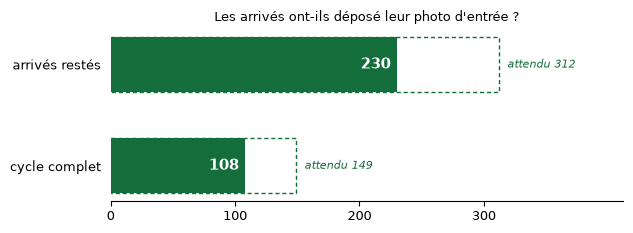

In [5]:
import matplotlib.pyplot as plt, matplotlib
matplotlib.rcParams["font.size"] = 9
fig, ax = plt.subplots(figsize=(6.4, 2.4))
labels = ["arrivés restés", "cycle complet"]
att = [len(Q[q]) for q in labels]
obs = [len(Q[q] & apres) for q in labels]        # version finale (après récupération)
for i in range(len(labels)):
    ax.barh(i, att[i], color="none", edgecolor="#146e3c", linestyle=(0,(3,2)), height=0.54, zorder=1)
    ax.barh(i, obs[i], color="#146e3c", height=0.54, zorder=2)
    ax.text(obs[i]-5, i, f"{obs[i]}", ha="right", va="center", color="white", fontsize=11, fontweight="bold")
    ax.text(att[i]+7, i, f"attendu {att[i]}", ha="left", va="center", color="#146e3c", fontsize=8, style="italic")
ax.set_yticks([0,1]); ax.set_yticklabels(labels)
ax.set_xlim(0, max(att)*1.32); ax.invert_yaxis(); ax.set_xticks([0,100,200,300])
for s in ("top","right","left"): ax.spines[s].set_visible(False)
ax.tick_params(left=False)
ax.set_title("Les arrivés ont-ils déposé leur photo d'entrée ?", fontsize=9.5, pad=6)
plt.tight_layout()
plt.savefig("figures_house/fig_recup_photos.png", dpi=200, bbox_inches="tight")
print(f"figure écrite : observé {obs} / attendu {att}")
plt.show()
